In [1]:
# Libraries
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
import pyarrow.dataset as ds
from collections import defaultdict
import pandas as pd

### Building R and X matrix for calculating Voltages later.

In [2]:
## Building the R and X matrices for the linearized voltage model
## These are also sensitivity matrices for how load changes at each bus affect voltage at each bus, relative to the root bus.

def build_tree_from_lines(line_df, root=114):

    children = defaultdict(list)
    parent = {}
    edge_rx = {}

    for _, row in line_df.iterrows():
        i = int(row["upstream bus"])
        j = int(row["downstream bus"])
        r = float(row["series resistance (pu)"])
        x = float(row["series reactance (pu)"])

        children[i].append(j)
        parent[j] = i
        edge_rx[(i, j)] = (r, x)

    buses = sorted(set(line_df["upstream bus"]).union(set(line_df["downstream bus"])))
    non_root = [b for b in buses if b != root]

    return children, parent, edge_rx, buses, non_root


# It returns the list of edges on the path from a given bus to the root bus, in order from root to bus.
def path_edges_to_root(bus, parent):
    edges = []
    cur = bus
    while cur in parent:
        par = parent[cur]
        edges.append((par, cur))
        cur = par
    edges.reverse()
    return edges


def build_RX_matrices(line_df, root=0):
    
    children, parent, edge_rx, buses, non_root = build_tree_from_lines(line_df, root=root)
    n = len(non_root)

    bus_to_idx = {b: k for k, b in enumerate(non_root)}
    path_map = {b: path_edges_to_root(b, parent) for b in non_root}

    R = np.zeros((n, n), dtype=float)
    X = np.zeros((n, n), dtype=float)

    for bi in non_root:
        for bj in non_root:
            common = set(path_map[bi]).intersection(set(path_map[bj]))  # Only the common edges contribute to the voltage drop difference between bi and bj
            r_sum = sum(edge_rx[e][0] for e in common)
            x_sum = sum(edge_rx[e][1] for e in common)

            i = bus_to_idx[bi]
            j = bus_to_idx[bj]
            R[i, j] = 2.0 * r_sum
            X[i, j] = 2.0 * x_sum

    return R, X, non_root, bus_to_idx

In [3]:
line_df = pd.read_csv("IEEE123 lines.csv")
R, X, non_root, bus_to_idx = build_RX_matrices(line_df, root=114)

### Building Bus loads

In [5]:
dataset = ds.dataset("dataset", format="parquet")
table = dataset.to_table()
df = table.to_pandas()
df = df[['timestamp', 'out.electricity.net.energy_consumption']]



In [6]:
buses = sorted(set(line_df["upstream bus"]).union(set(line_df["downstream bus"]))) # removing the root bus
buses.remove(114)
bldgs = df.index.get_level_values("bldg_id").unique()

np.random.seed(0)

bus_assignment = pd.DataFrame({
    "bldg_id": bldgs,
    "bus": np.random.choice(buses, size=len(bldgs))
})

In [7]:
df.reset_index(inplace=True)

df = df.merge(bus_assignment, on="bldg_id")

bus_load = (
    df
    .groupby(["timestamp","bus"])["out.electricity.net.energy_consumption"]
    .sum()
    .reset_index()
)

In [8]:
bus_load = bus_load.pivot(
    index="timestamp",
    columns="bus",
    values="out.electricity.net.energy_consumption"
)

bus_load = bus_load.fillna(0)

# Forcing all the buses to  exist even if they have no load
bus_load = bus_load.reindex(columns=buses, fill_value=0.0)

In [9]:
bus_load_kw = bus_load / 0.25 # Converting to KW : P = E/t



# --- Step 1: scale loads for voltage feasibility FIRST ---
peak_load_kw_raw = bus_load_kw.sum(axis=1).max()
S_base_temp = peak_load_kw_raw # temporary maximum power as base to calculate per-unit loads for voltage constraint evaluation.
bus_load_pu_temp = bus_load_kw / S_base_temp

pf = np.full(bus_load_pu_temp.shape[1], 0.9)
eta_bus = np.sqrt(1.0 / (pf ** 2) - 1.0)
Z = R + X @ np.diag(eta_bus)

v_base = 1.0 - (bus_load_pu_temp.to_numpy() @ Z.T)
vmin_actual = v_base.min()

print("Raw peak load (kW):", peak_load_kw_raw)
print("Minimum baseline voltage before scaling:", vmin_actual)

# scaling all loads down so minimum voltage becomes 0.95 p.u.
scale_voltage = (1.0 - 0.95) / (1.0 - vmin_actual)
bus_load_kw_scaled = bus_load_kw * scale_voltage


# Step 2: setting transformer capacity AFTER voltage scaling 
peak_load_kw_scaled = bus_load_kw_scaled.sum(axis=1).max()
S_base = peak_load_kw_scaled
bus_load_pu = bus_load_kw_scaled / S_base  # Converting to per unit

v_base = 1.0 - (bus_load_pu.to_numpy() @ Z.T)
vmin_actual = v_base.min()

print("\n")
print("Applied voltage scaling factor:", scale_voltage)
print("Peak load after voltage scaling (kW):", peak_load_kw_scaled)
print("Transformer rating S_base (kW):", S_base)
print("Peak load in pu after voltage scaling:", bus_load_pu.sum(axis=1).max())
print("Minimum baseline voltage after scaling:", vmin_actual)


# --- Step 3: further scale loads down to create headroom ---
bus_load_pu = 0.9 * bus_load_pu   # this is what we will use for the rest of analysis.
bus_load_kw_final = 0.9 * bus_load_kw_scaled # this is what we will use for the rest of analysis.

v_base = 1.0 - (bus_load_pu.to_numpy() @ Z.T)
vmin_final = v_base.min()

print("\n")
print("Final peak load after headroom scaling (kW):", bus_load_kw_final.sum(axis=1).max())
print("Transformer rating remains fixed (kW):", S_base)
print("Final peak load in pu:", bus_load_pu.sum(axis=1).max())
print("Minimum voltage after headroom scaling:", vmin_final)
print("Available headroom at peak (pu):", 1.0 - bus_load_pu.sum(axis=1).max())
print("Available headroom at peak (kW):", S_base - bus_load_kw_final.sum(axis=1).max())



Raw peak load (kW): 464.5039999999999
Minimum baseline voltage before scaling: 0.9463326002665228


Applied voltage scaling factor: 0.9316642924440125
Peak load after voltage scaling (kW): 432.76179049741353
Transformer rating S_base (kW): 432.76179049741353
Peak load in pu after voltage scaling: 1.0
Minimum baseline voltage after scaling: 0.9463326002665228


Final peak load after headroom scaling (kW): 389.4856114476723
Transformer rating remains fixed (kW): 432.76179049741353
Final peak load in pu: 0.8999999999999999
Minimum voltage after headroom scaling: 0.9516993402398705
Available headroom at peak (pu): 0.10000000000000009
Available headroom at peak (kW): 43.276179049741245


### EV Charging Dataset (Norway)

In [10]:
ev_df = pd.read_csv('EV/dataset_3a_aggregated.csv', sep=';')
ev_df = ev_df[['date_from', 'Synthetic_7_2kW']]

ev_df['Synthetic_7_2kW'] = (
    ev_df['Synthetic_7_2kW']
    .astype(str)
    .str.replace(',', '.', regex=False)
    .astype(float)
)

ev_df['date_from'] = pd.to_datetime(ev_df['date_from'], dayfirst=True)
ev_df = ev_df.set_index('date_from').sort_index()

ev_df.drop_duplicates(inplace=True)

# Resampling to 15-minutes interval
ev_df = ev_df.resample('15T').interpolate(method='linear')
ev_df =  ev_df.loc['2019-01-01 00:15:00':'2020-01-01 00:00:00']
ev_df.index = ev_df.index - pd.DateOffset(years=12)

C:\Users\gcsar\AppData\Local\Temp\ipykernel_13980\105924172.py:17: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  ev_df = ev_df.resample('15T').interpolate(method='linear')


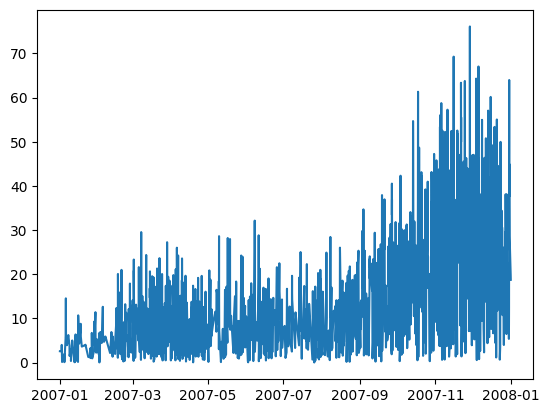

In [11]:
plt.plot(ev_df['Synthetic_7_2kW'])

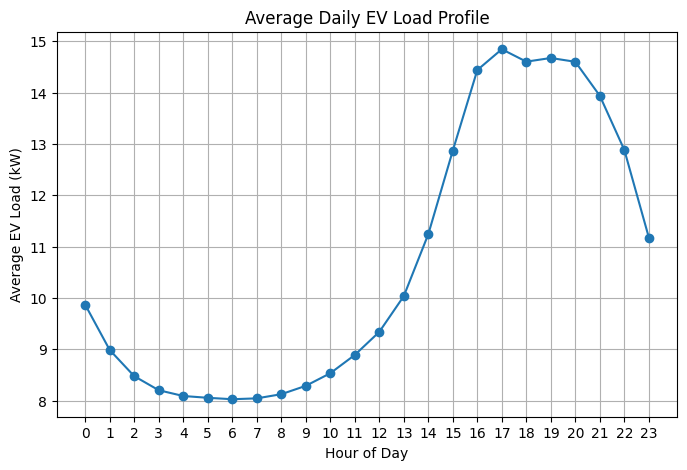

In [12]:
ev_df['hour'] = ev_df.index.hour

# Compute average load per hour
hourly_profile = ev_df.groupby('hour')['Synthetic_7_2kW'].mean()

# Plot
plt.figure(figsize=(8, 5))
plt.plot(hourly_profile.index, hourly_profile.values, marker='o')
plt.xlabel('Hour of Day')
plt.ylabel('Average EV Load (kW)')
plt.title('Average Daily EV Load Profile')
plt.grid(True)
plt.xticks(range(0, 24))
plt.show()

### Hosting Capacity

In [15]:
def dynamic_hosting_capacity_network(
    load_bus_t,          # shape (T, n), positive loads
    R, X,                # shape (n, n)
    lhat_new,            # shape (T,)
    host_idx,            # integer index of host bus in ordering
    p0_bar,              # transformer limit
    v0=1.0,
    vmin=0.95,
    pf=0.97,
):
    T, n = load_bus_t.shape

    vmin = np.full(n, float(vmin))
    pf = np.full(n, float(pf))
    eta_bus = np.sqrt(1.0 / (pf ** 2) - 1.0)

    C_res = np.full(T, np.inf, dtype=float)
    C_dyn = np.full(T, np.inf, dtype=float)

    l_agg = load_bus_t.sum(axis=1)

    # Z = R + X diag(eta)
    Z = R + X @ np.diag(eta_bus)

    for t in range(T):
        ell = load_bus_t[t, :]

        # transformer headroom
        headroom_tx = p0_bar - l_agg[t]

        # voltage headroom
        numerator = v0 - vmin - (Z @ ell)
        denominator = Z[:, host_idx]

        valid = denominator > 1e-12
        if np.any(valid):
            headroom_v = np.min(numerator[valid] / denominator[valid])
        else:
            headroom_v = np.inf

        C_res[t] = min(headroom_tx, headroom_v)

        if lhat_new[t] > 1e-12:
            C_dyn[t] = C_res[t] / lhat_new[t]
        else:
            C_dyn[t] = np.inf

    return C_res, C_dyn

### CVAR With No Curtailment Budget

In [13]:
# Normalized flexible load profile (EV charing profile in this case)

ev_profile = ev_df["Synthetic_7_2kW"].copy()
ev_profile = ev_profile.reindex(bus_load_pu.index)

# normalize
lhat = ev_profile.to_numpy(dtype=float)
lhat = lhat / lhat.max()

print("Length of lhat:", len(lhat))
print("Min/Max of lhat:", lhat.min(), lhat.max())

# or comment out all above and use the following dummy lhat for testing
# lhat = np.ones(len(bus_load_pu)) # Normalized load

Length of lhat: 35040
Min/Max of lhat: 0.0001314233144959916 1.0


In [16]:
T = len(bus_load_pu)


# candidate interconnection bus
host_bus_number = 13

host_idx = bus_to_idx[host_bus_number]

# limits
p0_bar = 1.0
v0 = 1.0
vmin = 0.95

C_res, C_dyn = dynamic_hosting_capacity_network(
    load_bus_t=bus_load_pu.to_numpy(),
    R=R,
    X=X,
    lhat_new=lhat,
    host_idx=host_idx,
    p0_bar=p0_bar,
    v0=v0,
    vmin=vmin,
    pf=0.9,
)


alpha = 0.95
epsilon = 0.0

# Decision variables
C = cp.Variable(nonneg=True, name="C")   # hosting capacity
eta = cp.Variable(name="eta")            # VaR-like auxiliary variable
s = cp.Variable(T, nonneg=True, name="s")# slack for tail losses


constraints = [
    s >= C * lhat - C_res - eta,
    eta + (1.0 / ((1.0 - alpha) * T)) * cp.sum(s) <= epsilon,
    C <= 1.0,
]

# Maximize hosting capacity
obj = cp.Maximize(C)

problem = cp.Problem(obj, constraints)
problem.solve(solver="ECOS", verbose=False)

print("Optimal radial CVaR hosting capacity C:", C.value)
print("In KW :", C.value * S_base)
print("Optimal eta:", eta.value)

Optimal radial CVaR hosting capacity C: 0.906155394173989
In KW : 392.149430851625
Optimal eta: -0.11313944826355046


#### Remarks
The optimal hosting capacity is the same as the transformer limit. The key equation is total_load = l^agg + C*lhat.
So, the ev load might be small when base load is in peak, thus allowing more capacity. I added a constraint s.t 
the hosting capacity is capped at feeder limit. Otherwise the hosting capacity goes beyond feeder limit. Because, we are using cvar (weaker constraint than the GU et al paper), so maximizing C will increase the limit a bit until it violates the tail risk by epsilon.

In [23]:
t_peak_feeder = np.argmax(bus_load_pu.sum(axis=1).to_numpy())
print("Feeder peak baseline load (pu):", bus_load_pu.sum(axis=1).max())
print("lhat at feeder peak:", lhat[t_peak_feeder])
print("Added load at feeder peak (pu):", C.value * lhat[t_peak_feeder])
print("Total load at feeder peak (pu):",
      bus_load_pu.sum(axis=1).to_numpy()[t_peak_feeder] + C.value * lhat[t_peak_feeder])

Feeder peak baseline load (pu): 0.8999999999999999
lhat at feeder peak: 1.0
Added load at feeder peak (pu): 0.2554304982096499
Total load at feeder peak (pu): 1.15543049820965


In [25]:
z = C.value * lhat - C_res
print("Max violation:", z.max())
print("Fraction violated:", np.mean(z > 1e-8))

Max violation: 0.5171725445576354
Fraction violated: 0.01937785388127854


### CVAR with Curtailment Budget

In [4]:
T = len(bus_load_pu)


# candidate interconnection bus
host_bus_number = 13

host_idx = bus_to_idx[host_bus_number]

# limits
p0_bar = 1.0
v0 = 1.0
vmin = 0.95

C_res, C_dyn = dynamic_hosting_capacity_network(
    load_bus_t=bus_load_pu.to_numpy(),
    R=R,
    X=X,
    lhat_new=lhat,
    host_idx=host_idx,
    p0_bar=p0_bar,
    v0=v0,
    vmin=vmin,
    pf=0.9,
)


alpha = 0.99
epsilon = 0.0

# Curtailment budget parameters
dt = 0.25      # 15-minute intervals = 0.25 hour
B_kwh = 1000   # total curtailment energy budget in KWh
mu = 0.1       # max 10% curtailment per timestamp


NameError: name 'bus_load_pu' is not defined

In [36]:
def optimize_C(
    C_res,
    lhat,
    alpha=alpha,
    epsilon=epsilon,
    mu=mu,
    B_kwh=B_kwh,
    dt=dt,
    S_base=S_base,
):
    

    # Decision variables
    C = cp.Variable(nonneg=True, name="C")     # hosting capacity
    eta = cp.Variable(name="eta")              # VaR-like auxiliary variable
    s = cp.Variable(T, nonneg=True, name="s")  # CVaR slack variables
    y = cp.Variable(T, nonneg=True, name="y")  # curtailed amount at each time

    zeta = C * lhat - y - C_res
    constraints = [
        # CVaR epigraph constraints
        s >= zeta - eta,
        eta + (1.0 / ((1.0 - alpha) * T)) * cp.sum(s) <= epsilon,

        # Curtailment feasibility constraints
        y <= C * lhat,          # cannot curtail more than the requested added load
        y <= mu * C * lhat,     # per-slot curtailment cap
        cp.sum(y) * dt * S_base <= B_kwh, # total curtailment energy budget
        C <= 1.0, # hosting capacity cannot exceed 1.0 p.u. of the base load
    ]

    # obj = cp.Maximize(C - cp.sum(y)) 
    obj = cp.Maximize(C) 
    problem = cp.Problem(obj, constraints)

    problem.solve(solver="ECOS", verbose=False)

    return [C.value, eta.value, y.value]


In [34]:
result = optimize_C(C_res, lhat)

print("Optimal radial CVaR hosting capacity C (pu):", result[0])
print("Optimal radial CVaR hosting capacity C (KW):", result[0] * S_base)
print("Optimal eta:", result[1])
print("Total curtailed energy (kWh):", np.sum(result[2]) * dt * S_base)
print("Max curtailment in any slot (pu):", np.max(result[2]))
print("Max curtailment in any slot (KW):", np.max(result[2]) * S_base)
print("Number of slots with curtailment:", np.sum(result[2] > 1e-8))

(CVXPY) Mar 21 05:25:19 PM: Your problem has 70082 variables, 105123 constraints, and 0 parameters.
(CVXPY) Mar 21 05:25:19 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Mar 21 05:25:19 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Mar 21 05:25:19 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Mar 21 05:25:19 PM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Mar 21 05:25:19 PM: Compiling problem (target solver=ECOS).
(CVXPY) Mar 21 05:25:19 PM: Reduction chain: FlipObjective -> Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> ECOS
(CVXPY) Mar 21 05:25:19 PM: Applying reduction FlipObjective
(CVXPY) Mar 21 05:25:19 PM: Applying reduction Dcp2Cone
(CVXPY) Mar 21 05:25:19 PM: Applying reduction CvxAttr2Constr
(CVXPY) Mar 21 05:25:19 PM: Applying reduction ConeMatrixStuffing
(CVXPY) Mar 21 05:25:19 PM: Appl

                                     CVXPY                                     
                                     v1.7.5                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------


(CVXPY) Mar 21 05:25:19 PM: Finished problem compilation (took 3.680e-01 seconds).
(CVXPY) Mar 21 05:25:19 PM: Invoking solver ECOS  to obtain a solution.


-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------


(CVXPY) Mar 21 05:25:27 PM: Problem status: optimal
(CVXPY) Mar 21 05:25:27 PM: Optimal value: 6.553e-01
(CVXPY) Mar 21 05:25:27 PM: Compilation took 3.680e-01 seconds
(CVXPY) Mar 21 05:25:27 PM: Solver (including time spent in interface) took 8.260e+00 seconds


-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------
Optimal radial CVaR hosting capacity C (pu): 0.6552629563879016
Optimal radial CVaR hosting capacity C (KW): 283.5727702530569
Optimal eta: -0.045783146814233615
Total curtailed energy (kWh): 1000.000000000045
Max curtailment in any slot (pu): 0.060176918047931766
Max curtailment in any slot (KW): 26.04227080103907
Number of slots with curtailment: 350


### Test Approach

In [44]:
# Approacch 2 reweighted l1
def optimize_C_stage1(C_res, lhat, alpha, epsilon, mu, B_kwh, dt, S_base):
    C = cp.Variable(nonneg=True)
    eta = cp.Variable()
    s = cp.Variable(T, nonneg=True)
    y = cp.Variable(T, nonneg=True)

    zeta = C * lhat - y - C_res

    constraints = [
        s >= zeta - eta,
        eta + (1.0 / ((1.0 - alpha) * T)) * cp.sum(s) <= epsilon,
        y <= C * lhat,
        y <= mu * C * lhat,
        cp.sum(y) * dt * S_base <= B_kwh,
        C <= 1.0,
    ]

    prob = cp.Problem(cp.Maximize(C), constraints)
    prob.solve(solver="ECOS", verbose=False)

    return C.value


def optimize_C_stage2_sparse(
    C_res,
    lhat,
    C_star,
    alpha=alpha,
    epsilon=epsilon,
    mu=mu,
    B_kwh=B_kwh,
    dt=dt,
    S_base=S_base,
    eps_C=1e-4,
    n_outer=5,
    delta=1e-4,
):
    weights = np.ones(T)
    best = None

    for _ in range(n_outer):
        C = cp.Variable(nonneg=True)
        eta = cp.Variable()
        s = cp.Variable(T, nonneg=True)
        y = cp.Variable(T, nonneg=True)

        zeta = C * lhat - y - C_res

        constraints = [
            s >= zeta - eta,
            eta + (1.0 / ((1.0 - alpha) * T)) * cp.sum(s) <= epsilon,
            y <= C * lhat,
            y <= mu * C * lhat,
            cp.sum(y) * dt * S_base <= B_kwh,
            C <= 1.0,
            C >= C_star - eps_C,
        ]

        prob = cp.Problem(
            cp.Minimize(cp.sum(cp.multiply(weights, y))),
            constraints
        )
        prob.solve(solver="ECOS", verbose=False)

        if prob.status not in ["optimal", "optimal_inaccurate"] or y.value is None:
            break

        y_val = np.maximum(y.value, 0)
        weights = 1.0 / (y_val + delta)

        best = {
            "C": C.value,
            "eta": eta.value,
            "y": y_val,
            "num_curtailed_slots": int(np.sum(y_val > 1e-8)),
            "curtailed_energy_kWh": np.sum(y_val) * dt * S_base,
        }

    return best


In [45]:
C_star = optimize_C_stage1(C_res, lhat, alpha, epsilon, mu, B_kwh, dt, S_base)

res_sparse = optimize_C_stage2_sparse(
    C_res=C_res,
    lhat=lhat,
    C_star=C_star,
    alpha=alpha,
    epsilon=epsilon,
    mu=mu,
    B_kwh=B_kwh,
    dt=dt,
    S_base=S_base,
    eps_C=1e-4,
    n_outer=5,
)

print("Stage-1 max C:", C_star, "pu and ", C_star * S_base, "kW")
print("Stage-2 C:", res_sparse["C"], "pu and ", res_sparse["C"] * S_base, "kW")
print("Optimal eta:", res_sparse["eta"])
print("Curtailed slots:", res_sparse["num_curtailed_slots"])
print("Curtailment energy:", res_sparse["curtailed_energy_kWh"])

print("Max curtailment in any slot (pu):", np.max(res_sparse["y"]))
print("Max curtailment in any slot (KW):", np.max(res_sparse["y"]) * S_base)
print("Number of slots with curtailment:", np.sum(res_sparse["y"] > 1e-8))

c:\Users\gcsar\anaconda3\envs\RL\lib\site-packages\cvxpy\problems\problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


Stage-1 max C: 0.6552629563879016 pu and  283.5727702530569 kW
Stage-2 C: 0.6551831625172021 pu and  283.53823851470224 kW
Optimal eta: -0.046363975815363785
Curtailed slots: 227
Curtailment energy: 1000.1156953064535
Max curtailment in any slot (pu): 0.06551831588640342
Max curtailment in any slot (KW): 28.353823693375077
Number of slots with curtailment: 227


In [51]:
max(res_sparse['y'][np.where(res_sparse['y'] > 1e-8)]*S_base)

np.float64(28.353823693375077)

In [ ]:
result = optimize_C(C_res, lhat)

print("Optimal radial CVaR hosting capacity C (pu):", result[0])
print("Optimal radial CVaR hosting capacity C (KW):", result[0] * S_base)
print("Optimal eta:", result[1])
print("Total curtailed energy (kWh):", np.sum(result[2]) * dt * S_base)
print("Max curtailment in any slot (pu):", np.max(result[2]))
print("Max curtailment in any slot (KW):", np.max(result[2]) * S_base)
print("Number of slots with curtailment:", np.sum(result[2] > 1e-8))

### Backup Generation Concept

In [18]:
lambda_y = 1e4   # large penalty on curtailment

# baseline feeder load from your notebook
load_bus_t = bus_load_pu.to_numpy()   # shape (T, n)
T, n = load_bus_t.shape

# candidate interconnection bus
host_bus_number = 13
host_idx = bus_to_idx[host_bus_number]

# datacenter target capacity
C_target = 100 / S_base   # 100 kW target capacity in per unit
lhat = np.ones(T)

# Decision variables
P_gen = cp.Variable(nonneg=True, name="P_gen")      # generator rating (pu)
p_gen = cp.Variable(T, nonneg=True, name="p_gen")   # generator dispatch (pu)
y = cp.Variable(T, nonneg=True, name="y")           # curtailment (pu)

# unit vector for host bus
e_host = np.zeros(n)
e_host[host_idx] = 1.0

constraints = [
    p_gen <= P_gen,
    y <= C_target * lhat
]

# Uncomment this for strict zero curtailment
# constraints += [y == 0]

for t in range(T):
    # baseline feeder load at time t
    ell_t = load_bus_t[t, :]   # this replaces ell

    # net new load after generator and curtailment
    net_dc = C_target * lhat[t] - p_gen[t] - y[t]

    # real-power injection vector
    # baseline loads + datacenter load
    p_t = -ell_t - e_host * net_dc

    v_t = v0 * np.ones(n) + Z @ p_t

    

    constraints += [
        v_t >= vmin,
        -cp.sum(p_t) <= p0_bar
    ]

objective = cp.Minimize(
    P_gen + lambda_y * cp.sum(y) * dt
)

problem = cp.Problem(objective, constraints)
problem.solve(solver="ECOS", verbose=True)

print("Status:", problem.status)
print("Required generator size (pu):", P_gen.value)
print("Required generator size (kW):", P_gen.value * S_base)

if y.value is not None:
    print("Total curtailed energy (kWh):", np.sum(y.value) * dt * S_base)
    print("Max curtailment (pu):", np.max(y.value))
    print("Max curtailment (kW):", np.max(y.value) * S_base)

if p_gen.value is not None:
    print("Max generator dispatch (pu):", np.max(p_gen.value))
    print("Max generator dispatch (kW):", np.max(p_gen.value) * S_base)

                                     CVXPY                                     
                                     v1.7.5                                    


(CVXPY) Mar 21 01:36:52 AM: Your problem has 70081 variables, 4064640 constraints, and 0 parameters.
(CVXPY) Mar 21 01:36:58 AM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Mar 21 01:36:58 AM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Mar 21 01:36:58 AM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Mar 21 01:36:58 AM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Mar 21 01:37:06 AM: Compiling problem (target solver=ECOS).
(CVXPY) Mar 21 01:37:06 AM: Reduction chain: Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> ECOS
(CVXPY) Mar 21 01:37:06 AM: Applying reduction Dcp2Cone


-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------


(CVXPY) Mar 21 01:37:22 AM: Applying reduction CvxAttr2Constr
(CVXPY) Mar 21 01:37:35 AM: Applying reduction ConeMatrixStuffing
(CVXPY) Mar 21 12:42:50 PM: Applying reduction ECOS
(CVXPY) Mar 21 12:43:01 PM: Finished problem compilation (took 3.996e+04 seconds).
(CVXPY) Mar 21 12:43:01 PM: Invoking solver ECOS  to obtain a solution.


-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------


c:\Users\gcsar\anaconda3\envs\RL\lib\site-packages\cvxpy\problems\problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
(CVXPY) Mar 21 12:44:54 PM: Problem status: optimal_inaccurate
(CVXPY) Mar 21 12:44:54 PM: Optimal value: 3.107e-02
(CVXPY) Mar 21 12:44:54 PM: Compilation took 3.996e+04 seconds
(CVXPY) Mar 21 12:44:54 PM: Solver (including time spent in interface) took 1.085e+02 seconds


-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------
Status: optimal_inaccurate
Required generator size (pu): 0.03107400467308175
Required generator size (kW): 13.447641900247852
Total curtailed energy (kWh): 2.272648453290968e-11
Max curtailment (pu): 2.1005999172697766e-13
Max curtailment (kW): 9.090593813163872e-11
Max generator dispatch (pu): 0.031074004673288018
Max generator dispatch (kW): 13.447641900337118


### Plots

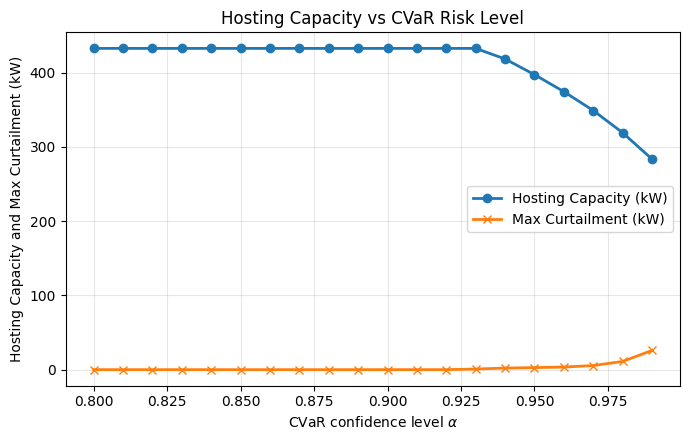

In [41]:
# Hosting Capacity vs Risk level alpha

alpha_grid = np.linspace(0.80, 0.99, 20)

C_kw_list = []
max_curtailment_kw_list = []

for alpha in alpha_grid:
    result = optimize_C(C_res, lhat, alpha=alpha)
    C_kw_list.append(result[0] * S_base)
    max_curtailment_kw_list.append(np.max(result[2]) * S_base)



# -----------------------------
# Plot in kW
# -----------------------------
plt.figure(figsize=(7, 4.5))
plt.plot(alpha_grid, C_kw_list, marker='o', linewidth=2, label='Hosting Capacity (kW)')
plt.plot(alpha_grid, max_curtailment_kw_list, marker='x', linewidth=2, label='Max Curtailment (kW)')
plt.xlabel(r'CVaR confidence level $\alpha$')
plt.ylabel('Hosting Capacity and Max Curtailment (kW)')
plt.title('Hosting Capacity vs CVaR Risk Level')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()



#### Remarks

If we increase the confidence level, the hosting capacity decrease. However the maximum curtailment doesn't decrease much.

In [ ]:
# Hosting capacity with curtailment budget
